### Netflix Data Analysis

#### Introduction
This notebook performs exploratory data analysis (EDA) on the Netflix Movies & TV Shows dataset obtained from Kaggle. The dataset contains information about titles, cast, directors, ratings, genres, duration, and release dates.

Using Python libraries such as Pandas, Plotly Express, and Datetime, we analyze trends and answer key business questions about:
- Monthly and yearly content additions
- Ratings distribution
- Popular actors and directors
- Movie durations and TV show seasons
- Genre popularity
- Bollywood actor-based analysis

The goal is to uncover insights and understand Netflix content patterns.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
from datetime import datetime

Reading excel file using pandas

In [4]:
df = pd.read_csv("netflix_movies.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [6]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [7]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [10]:
df.shape

(8807, 12)

In [11]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [15]:
#Filling "unkonwn" at the place of null values
df['director'].fillna('Unknown', inplace=True)
df['cast'].fillna('Unknown', inplace=True)
df['country'].fillna('Unknown', inplace=True)
df['rating'].fillna('Not rated', inplace=True)

In [16]:
df.isnull().sum()

show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      10
release_year     0
rating           0
duration         3
listed_in        0
description      0
dtype: int64

In [26]:
df['date_added'].dtype

dtype('<M8[ns]')

# date_added
convert the data in the column 'date_added' from its current format (likely text/strings or objects) into a standardized Pandas datetime object (specifically, datetime64). 
What it does:
- Identifies the Column
- Converts Type
- Standardizes Formats
- Reassigns Column

Why this is necessary:
-When data is loaded into Pandas from CSVs, Excel, or SQL, date columns are often treated as object (string) types. As strings, you cannot perform time-based calculations. 

In [24]:
df['date_added'] = df['date_added'].astype(str).str.strip()
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

In [27]:
df['month_added'] = df['date_added'].dt.month_name()

In [37]:
month_counts = df['month_added'].value_counts().reset_index()
month_counts.columns = ['Month', 'Count']
print(month_counts)

        Month  Count
0        July    827
1    December    813
2   September    770
3       April    764
4     October    760
5      August    755
6       March    742
7     January    738
8        June    728
9    November    705
10        May    632
11   February    563


Show the all Movies & TV Shows released by month

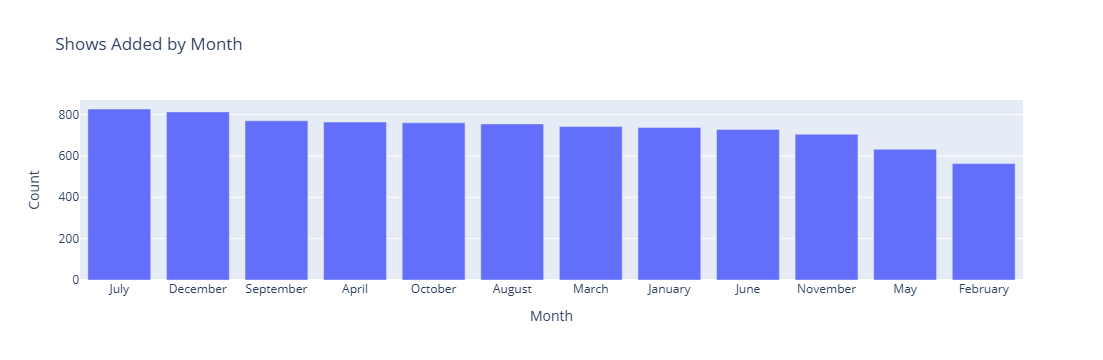

In [38]:
fig = px.bar(month_counts, x='Month', y='Count', title='Shows Added by Month')
fig.show()


Count the all types of unique rating & which rating are with most number

In [39]:
rating_counts = df['rating'].value_counts().reset_index()
rating_counts.columns = ['Rating', 'Count']

print(rating_counts)

       Rating  Count
0       TV-MA   3207
1       TV-14   2160
2       TV-PG    863
3           R    799
4       PG-13    490
5       TV-Y7    334
6        TV-Y    307
7          PG    287
8        TV-G    220
9          NR     80
10          G     41
11   TV-Y7-FV      6
12  Not rated      4
13      NC-17      3
14         UR      3
15     66 min      1
16     74 min      1
17     84 min      1


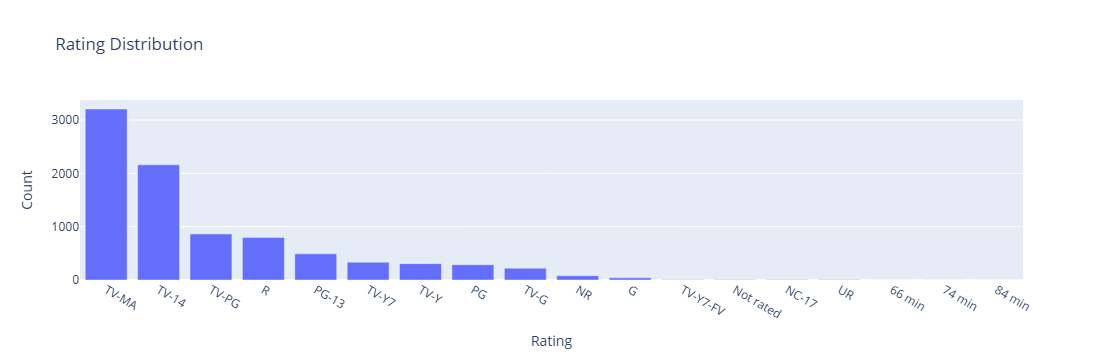

In [40]:
px.bar(rating_counts, x='Rating', y='Count', title='Rating Distribution').show()


Salman, Shah Rukh and Akshay Kumar all movie

In [41]:
movies = df[df['type'] == 'Movie']


In [44]:
salman = movies[movies['cast'].str.contains('Salman Khan', na=False)]
shahrukh = movies[movies['cast'].str.contains('Shah Rukh Khan', na=False)]
akshay = movies[movies['cast'].str.contains('Akshay Kumar', na=False)]

salman[['title','release_year']]

,title,release_year
1441,Hello Brother,1999
1674,Bodyguard,2011
2339,Prem Ratan Dhan Payo,2015
2545,Andaz Apna Apna,1994
2734,Kuch Kuch Hota Hai,1998
2756,Paharganj,2019
2957,Hum Aapke Hain Koun,1994
2969,Together For Eternity,1999
4729,Main aurr Mrs. Khanna,2009
5718,Mumbai Cha Raja,2012


In [45]:
shahrukh[['title', 'release_year']]

,title,release_year
114,Anjaam,1994
301,Chennai Express,2013
2722,Duplicate,1998
2730,Kabhi Alvida Naa Kehna,2006
2731,Kabhi Khushi Kabhie Gham,2001
2732,Kal Ho Naa Ho,2003
2734,Kuch Kuch Hota Hai,1998
3133,Don,2006
3134,Don 2,2011
3376,My Next Guest with David Letterman and Shah Ru...,2019


In [46]:
akshay[['title', 'release_year']]

,title,release_year
209,Once Upon a Time in Mumbai Dobaara!,2013
1305,Awara Paagal Deewana,2002
1865,Phir Hera Pheri,2006
1946,Welcome,2007
2268,Boss,2013
2273,Gabbar Is Back,2015
2281,Oh My God,2012
2289,Special 26,2013
2544,Action Replayy,2010
2716,Brothers,2015


Find out the Movies & Series have Maximum time length

In [48]:
df[['length','unit']] = df['duration'].str.split(' ', expand=True)

df['length'] = pd.to_numeric(df['length'], errors='coerce')

In [50]:
#longest movies
df[df['unit']=='min'].sort_values('length', ascending=False).head()


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,month_added,length,unit
4253,s4254,Movie,Black Mirror: Bandersnatch,unknown,"Fionn Whitehead, Will Poulter, Craig Parkinson...",United States,2018-12-28,2018,TV-MA,312 min,"Dramas, International Movies, Sci-Fi & Fantasy","In 1984, a young programmer begins to question...",December,312.0,min
717,s718,Movie,Headspace: Unwind Your Mind,unknown,"Andy Puddicombe, Evelyn Lewis Prieto, Ginger D...",unknown,2021-06-15,2021,TV-G,273 min,Documentaries,"Do you want to relax, meditate or sleep deeply...",June,273.0,min
2491,s2492,Movie,The School of Mischief,Houssam El-Din Mustafa,"Suhair El-Babili, Adel Emam, Saeed Saleh, Youn...",Egypt,2020-05-21,1973,TV-14,253 min,"Comedies, Dramas, International Movies",A high school teacher volunteers to transform ...,May,253.0,min
2487,s2488,Movie,No Longer kids,Samir Al Asfory,"Said Saleh, Hassan Moustafa, Ahmed Zaki, Youne...",Egypt,2020-05-21,1979,TV-14,237 min,"Comedies, Dramas, International Movies",Hoping to prevent their father from skipping t...,May,237.0,min
2484,s2485,Movie,Lock Your Girls In,Fouad El-Mohandes,"Fouad El-Mohandes, Sanaa Younes, Sherihan, Ahm...",unknown,2020-05-21,1982,TV-PG,233 min,"Comedies, International Movies, Romantic Movies",A widower believes he must marry off his three...,May,233.0,min


In [51]:
#most seasons
df[df['unit']=='Season'].sort_values('length', ascending=False).head()


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,month_added,length,unit
8800,s8801,TV Show,Zindagi Gulzar Hai,unknown,"Sanam Saeed, Fawad Khan, Ayesha Omer, Mehreen ...",Pakistan,2016-12-15,2012,TV-PG,1 Season,"International TV Shows, Romantic TV Shows, TV ...","Strong-willed, middle-class Kashaf and carefre...",December,1.0,Season
8604,s8605,TV Show,Top 10 Secrets and Mysteries,unknown,unknown,"United Kingdom, United States, Czech Republic",2019-03-15,2018,TV-14,1 Season,"British TV Shows, Docuseries, Science & Nature TV",This series investigates mysteries that persis...,March,1.0,Season
8596,s8597,TV Show,Tip the Mouse,unknown,"Alyson Leigh Rosenfeld, Dave Wills, Serra Hirs...","Germany, United States, Italy",2017-09-01,2014,TV-Y,1 Season,Kids' TV,"In his tiny meadow village, curious little mou...",September,1.0,Season
8593,s8594,TV Show,Timeline,unknown,"Santiwithi Phrombut, Jamorn Kijsawapak, Orrawa...",unknown,2018-02-23,2014,TV-14,1 Season,"Crime TV Shows, Docuseries, International TV S...","Firsthand accounts, re-enactments and computer...",February,1.0,Season
8592,s8593,TV Show,Timeless Season,unknown,"Loo Aye Keng, Chen Ke Mei, Hady, Hishiko Woo, ...",unknown,2017-09-18,2009,TV-14,1 Season,"International TV Shows, TV Dramas","A decade after college, a wake reunites five f...",September,1.0,Season


Year on Year show added on Netflix by its type

In [52]:
df['year_added'] = df['date_added'].dt.year

year_type = df.groupby(['year_added','type']).size().reset_index(name='count')


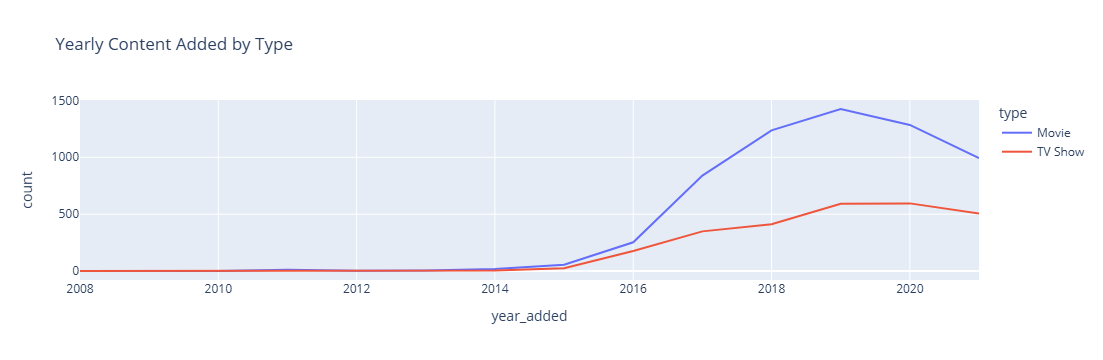

In [53]:
px.line(year_type, x='year_added', y='count', color='type',
        title='Yearly Content Added by Type').show()


Akshay Kumar all comedies movies, Shah Rukh movies with Kajol and Salman-Akshay Movies

In [60]:
akshay_comedy = df[
    (df['cast'].str.contains('Akshay Kumar', na=False)) &
    (df['listed_in'].str.contains('Comedy', na=False))
]
akshay_comedy

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,month_added,length,unit,year_added


In [58]:
srk_kajol = df[
    (df['cast'].str.contains('Shah Rukh Khan', na=False)) &
    (df['cast'].str.contains('Kajol', na=False))
]
srk_kajol

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,month_added,length,unit,year_added
2731,s2732,Movie,Kabhi Khushi Kabhie Gham,Karan Johar,"Amitabh Bachchan, Jaya Bhaduri, Shah Rukh Khan...",India,2020-04-01,2001,TV-14,209 min,"Dramas, International Movies",Years after his father disowns his adopted bro...,April,209.0,min,2020.0
2734,s2735,Movie,Kuch Kuch Hota Hai,Karan Johar,"Shah Rukh Khan, Kajol, Rani Mukerji, Farida Ja...",India,2020-04-01,1998,TV-14,185 min,"Comedies, Dramas, International Movies","Per her mother’s last wish, a girl sets out to...",April,185.0,min,2020.0
5616,s5617,Movie,Dilwale,Rohit Shetty,"Shah Rukh Khan, Kajol, Kriti Sanon, Kabir Bedi...",India,2017-02-01,2015,TV-PG,154 min,"Action & Adventure, Dramas, International Movies","A young couple falls in love, but conflicting ...",February,154.0,min,2017.0


In [59]:
salman_akshay = df[
    (df['cast'].str.contains('Salman Khan', na=False)) &
    (df['cast'].str.contains('Akshay Kumar', na=False))
]
salman_akshay

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,month_added,length,unit,year_added
7109,s7110,Movie,Jaan-E-Mann: Let's Fall in Love... Again,Shirish Kunder,"Salman Khan, Akshay Kumar, Preity Zinta, Anupa...",India,2019-12-31,2006,TV-14,163 min,"Dramas, International Movies, Romantic Movies","To avoid alimony payments, an aspiring actor s...",December,163.0,min,2019.0
7524,s7525,Movie,Mujhse Shaadi Karogi,David Dhawan,"Rajpal Yadav, Amrish Puri, Kader Khan, Shashi ...",India,2019-12-31,2004,TV-PG,158 min,"Comedies, International Movies, Romantic Movies","Samir must overcome a hostile horoscope, a hot...",December,158.0,min,2019.0


Who Director has made the most TV Shows

In [62]:
tv = df[df['type']=='TV Show']

top_directors = tv['director'].value_counts().head(10)
top_directors


director
unknown                2446
Alastair Fothergill       3
Rob Seidenglanz           2
Ken Burns                 2
Stan Lathan               2
Shin Won-ho               2
Hsu Fu-chun               2
Iginio Straffi            2
Jason Hehir               1
Gerhard Mostert           1
Name: count, dtype: int64

Actors and Actress who have given most Number of Movies

In [63]:
actors = df['cast'].str.split(', ', expand=True).stack()
actors = actors.value_counts().head(10)

print(actors)


unknown             825
Anupam Kher          43
Shah Rukh Khan       35
Julie Tejwani        33
Naseeruddin Shah     32
Takahiro Sakurai     32
Rupa Bhimani         31
Om Puri              30
Akshay Kumar         30
Yuki Kaji            29
Name: count, dtype: int64


Find out which types of genre has most movies and TV Shows

In [64]:
genres = df['listed_in'].str.split(', ', expand=True).stack()
genre_counts = genres.value_counts().head(10)

print(genre_counts)


International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64


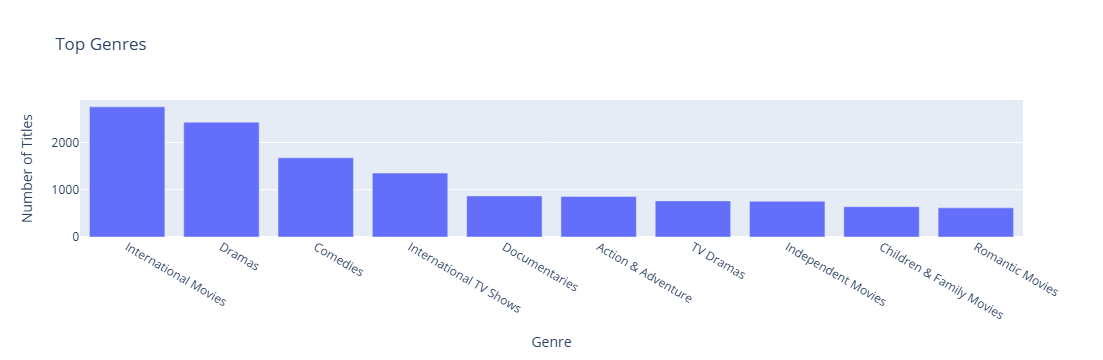

In [69]:
px.bar(
    x=genre_counts.index,
    y=genre_counts.values,
    title='Top Genres',
    labels={'x': 'Genre', 'y': 'Number of Titles'}
).show()



## Conclusion

In this notebook, we performed exploratory data analysis on the Netflix Movies and TV Shows dataset. Using Pandas, Plotly Express, and Datetime libraries, we cleaned the data and analyzed it step by step to answer all the given questions.
We examined monthly and yearly content additions, ratings distribution, movie durations, popular genres, and identified the most frequent actors, actresses, and directors. We also explored Bollywood actors’ movies and collaborations to understand content trends. 
Overall, this analysis helped uncover useful insights and patterns about Netflix’s content growth, popularity, and viewer preferences.

